In [83]:
import numpy as np
import pandas as pd
import missingno
pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [84]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data/'

In [85]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [86]:
data = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [87]:
try:
    data.drop(columns=['Unnamed: 0'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

In [88]:
try:
    data.drop(columns=['Unnamed: 0.1'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

No column named 'Unnamed: 0'


<Axes: >

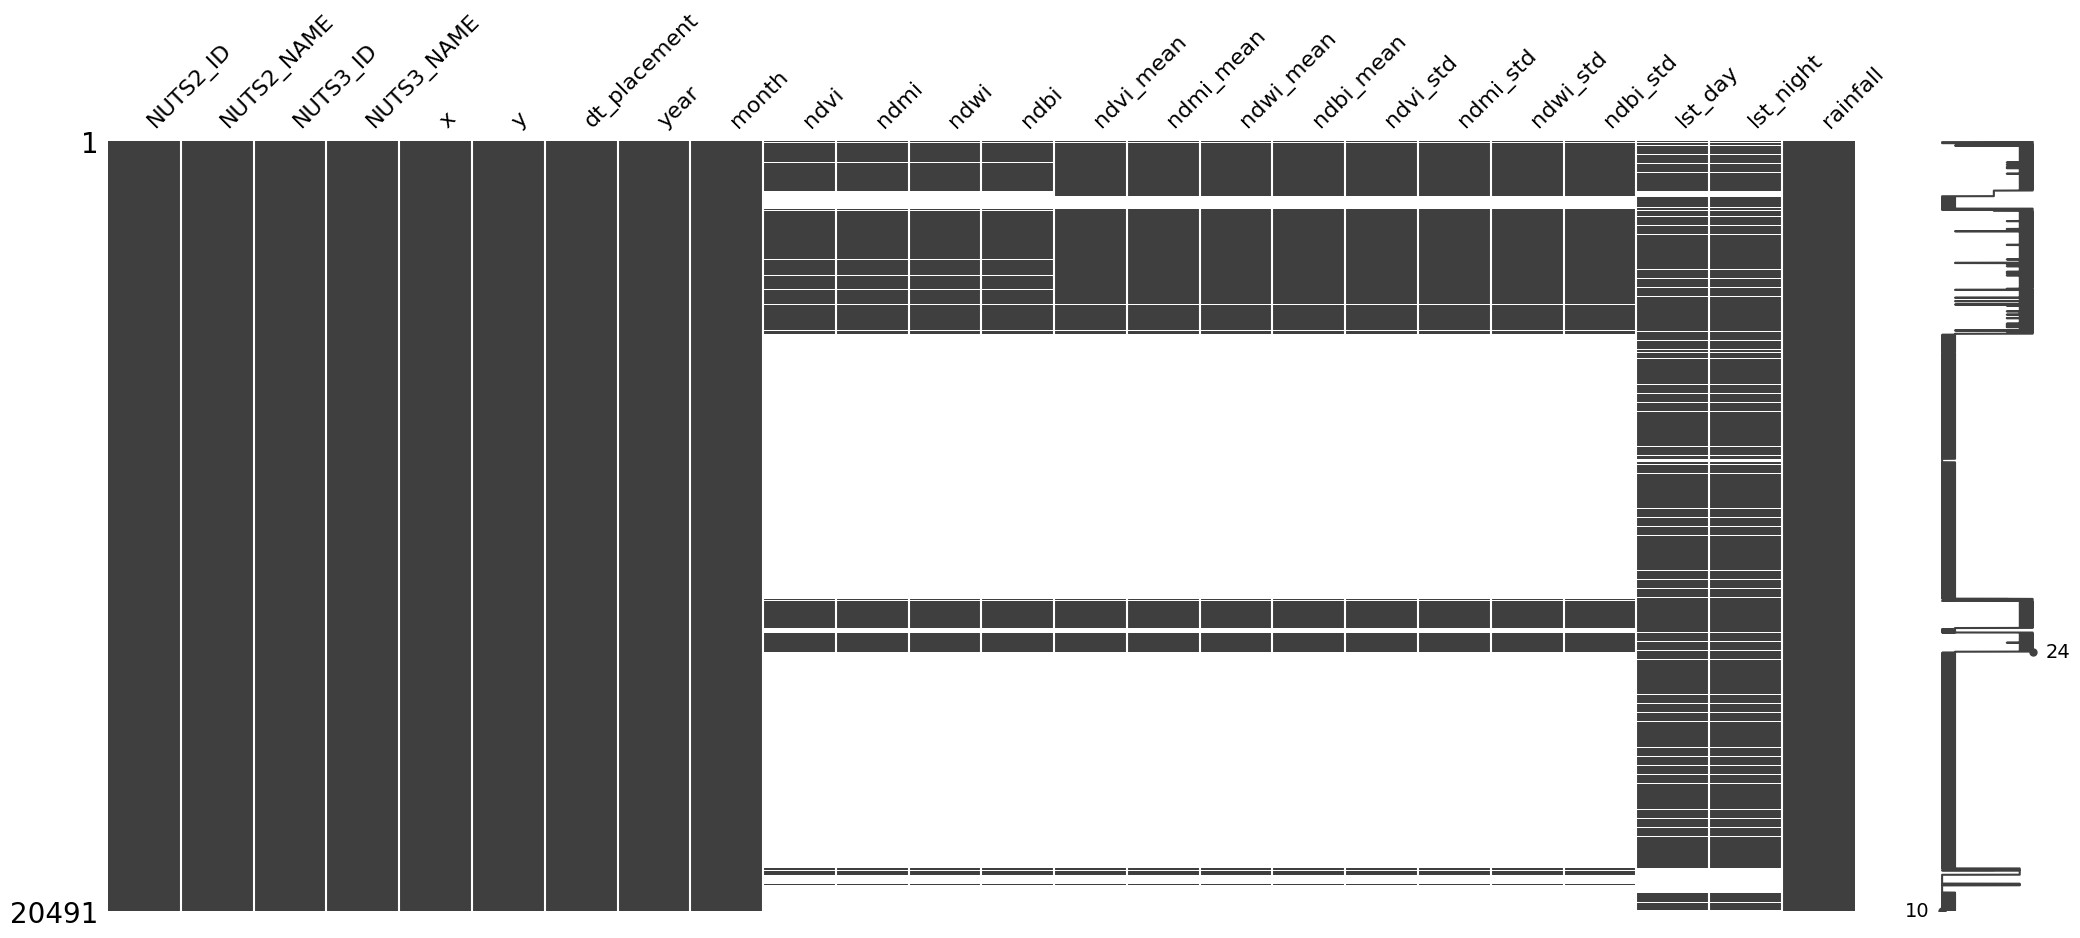

In [89]:
missingno.matrix(data)

In [90]:
data.dtypes

NUTS2_ID         object
NUTS2_NAME       object
NUTS3_ID         object
NUTS3_NAME       object
x               float64
y               float64
dt_placement     object
year              int64
month             int64
ndvi            float64
ndmi            float64
ndwi            float64
ndbi            float64
ndvi_mean       float64
ndmi_mean       float64
ndwi_mean       float64
ndbi_mean       float64
ndvi_std        float64
ndmi_std        float64
ndwi_std        float64
ndbi_std        float64
lst_day         float64
lst_night       float64
rainfall        float64
dtype: object

In [91]:
data

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-05-02,2024,5,0.296903,0.028477,-0.292196,-0.028477,0.425772,0.117267,-0.359087,-0.117267,0.025379,0.014299,0.014216,0.014299,14456.0,14121.0,0.095816
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-05-03,2024,5,0.296903,0.028477,-0.292196,-0.028477,0.425772,0.117267,-0.359087,-0.117267,0.025379,0.014299,0.014216,0.014299,14481.0,14121.0,2.594959
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-05-04,2024,5,0.296903,0.028477,-0.292196,-0.028477,0.425772,0.117267,-0.359087,-0.117267,0.025379,0.014299,0.014216,0.014299,14481.0,14121.0,0.333090
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-05-05,2024,5,0.296903,0.028477,-0.292196,-0.028477,0.425772,0.117267,-0.359087,-0.117267,0.025379,0.014299,0.014216,0.014299,14589.0,14029.0,0.000000
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-05-06,2024,5,0.296903,0.028477,-0.292196,-0.028477,0.425772,0.117267,-0.359087,-0.117267,0.025379,0.014299,0.014216,0.014299,14808.0,14224.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20486,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,40.91163,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
20487,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.23503,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
20488,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.19910,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
20489,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,41.19910,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


<Axes: >

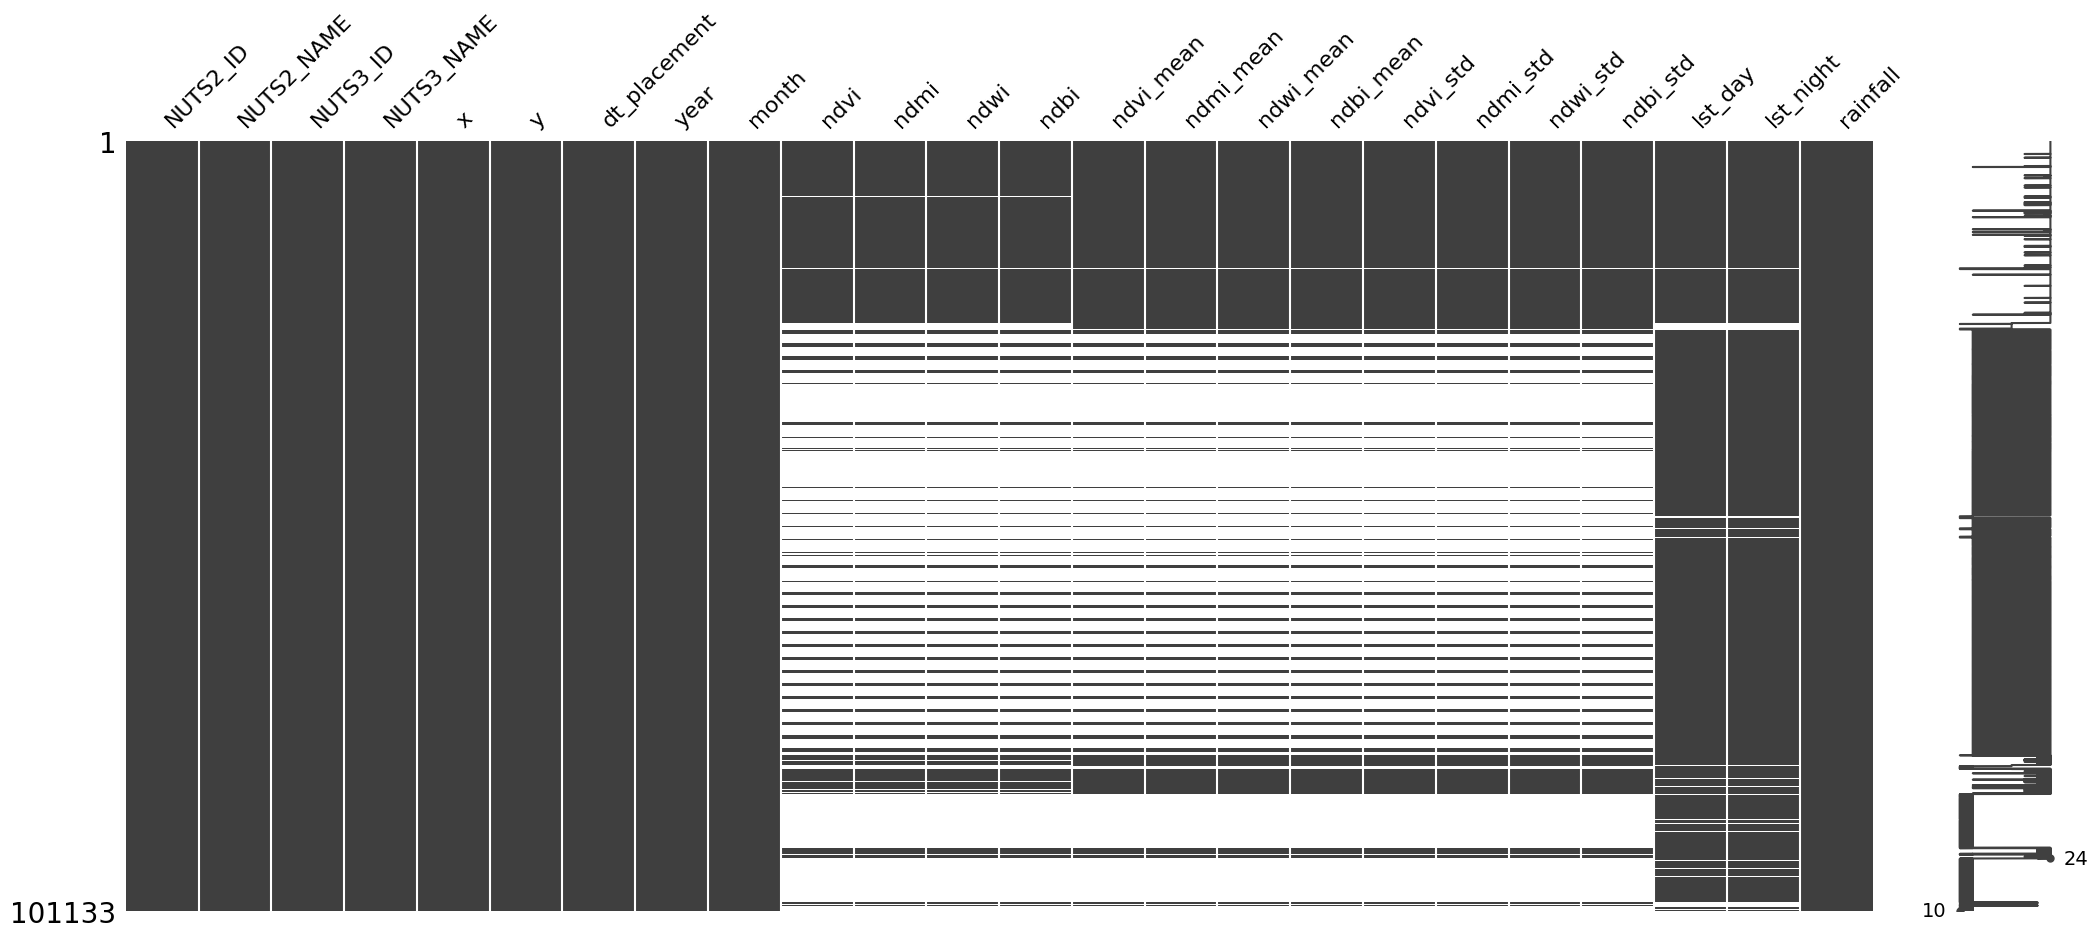

In [92]:
data_old = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled_mean_rain.csv', encoding=enc)
data_old_subset = data_old[data.columns]

data = pd.concat([data_old_subset, data], axis=0, ignore_index=True)
missingno.matrix(data)

In [93]:
# data.lst_day.unique()

In [94]:
# data['lst_day'] = data['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [95]:
# data['lst_day'] = data['lst_day'].astype(float)

In [96]:
# data.drop(columns=['rainfall.1'], inplace=True)

In [97]:
data['dt_placement'] = pd.to_datetime(data['dt_placement'])

# Extract year, month, and day from the 'date' column
data['year'] = data['dt_placement'].dt.year
data['month'] = data['dt_placement'].dt.month
data['day'] = data['dt_placement'].dt.day

In [98]:
data

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-01,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.0,13676.0,0.001530,1
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-02,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.0,13755.0,0.310446,2
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-03,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.0,13755.0,0.512597,3
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-04,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.0,13905.0,0.000000,4
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-05,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.0,13905.0,0.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101128,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,40.91163,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1
101129,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.23503,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1
101130,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.19910,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1
101131,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,41.19910,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1


In [99]:
data_jan = data.loc[data['month'] == 1]
data_fed = data.loc[data['month'] == 2]
data_mar = data.loc[data['month'] == 3]
data_apr = data.loc[data['month'] == 4]

In [100]:
df_mean_jan = data_jan.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_feb = data_fed.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_mar = data_mar.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_apr = data_apr.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()

In [101]:
df_mean_jan.rename(columns={'lst_day': 'lst_day_jan_mean', 'lst_night': 'lst_night_jan_mean'}, inplace=True)
df_mean_feb.rename(columns={'lst_day': 'lst_day_feb_mean', 'lst_night': 'lst_night_feb_mean'}, inplace=True)
df_mean_mar.rename(columns={'lst_day': 'lst_day_mar_mean', 'lst_night': 'lst_night_mar_mean'}, inplace=True)
df_mean_apr.rename(columns={'lst_day': 'lst_day_apr_mean', 'lst_night': 'lst_night_apr_mean'}, inplace=True)

In [102]:
df_mean_jan.drop(columns=['month'], inplace = True)
df_mean_feb.drop(columns=['month'], inplace = True)
df_mean_mar.drop(columns=['month'], inplace = True)
df_mean_apr.drop(columns=['month'], inplace = True)

In [103]:
df_mean = pd.merge(df_mean_jan, df_mean_feb, on=['NUTS3_ID', 'year']).merge(df_mean_mar, on=['NUTS3_ID', 'year']).merge(df_mean_apr, on=['NUTS3_ID', 'year'])

In [105]:
df_mean.loc[(df_mean['NUTS3_ID'] == 'EL511') & (df_mean['year'] == 2024)]

,NUTS3_ID,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,EL511,2024,14086.249032,13726.772419,14341.048276,13920.649138,14444.408548,13928.65129,14865.1515,14220.632667


In [106]:
df_mean

,NUTS3_ID,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,EL511,2024,14086.249032,13726.772419,14341.048276,13920.649138,14444.408548,13928.651290,14865.151500,14220.632667
1,EL512,2024,14049.217742,13662.883468,14253.852586,13831.589655,14404.359274,13920.600403,14809.900833,14222.193750
2,EL513,2024,14099.633715,13711.818158,14306.535039,13899.578420,14459.404266,13932.547867,14842.184409,14233.125806
3,EL514,2024,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487
4,EL515,2024,14073.050747,13755.566876,14256.981918,13889.698486,14362.148308,13972.516522,14821.921138,14266.569512


In [107]:
data_mean = pd.merge(data, df_mean, on=['NUTS3_ID', 'year'])

In [108]:
data_mean

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-01,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.0,13676.0,0.001530,1,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-02,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.0,13755.0,0.310446,2,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-03,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.0,13755.0,0.512597,3,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-04,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.0,13905.0,0.000000,4,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.69482,41.34493,2024-01-05,2024,1,0.284574,-0.14387,-0.272169,0.14387,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.0,13905.0,0.000000,5,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101128,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,40.91163,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,14099.633715,13711.818158,14306.535039,13899.578420,14459.404266,13932.547867,14842.184409,14233.125806
101129,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.23503,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,14099.633715,13711.818158,14306.535039,13899.578420,14459.404266,13932.547867,14842.184409,14233.125806
101130,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.19910,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,14099.633715,13711.818158,14306.535039,13899.578420,14459.404266,13932.547867,14842.184409,14233.125806
101131,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,41.19910,2024-06-01,2024,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,14099.633715,13711.818158,14306.535039,13899.578420,14459.404266,13932.547867,14842.184409,14233.125806


<Axes: >

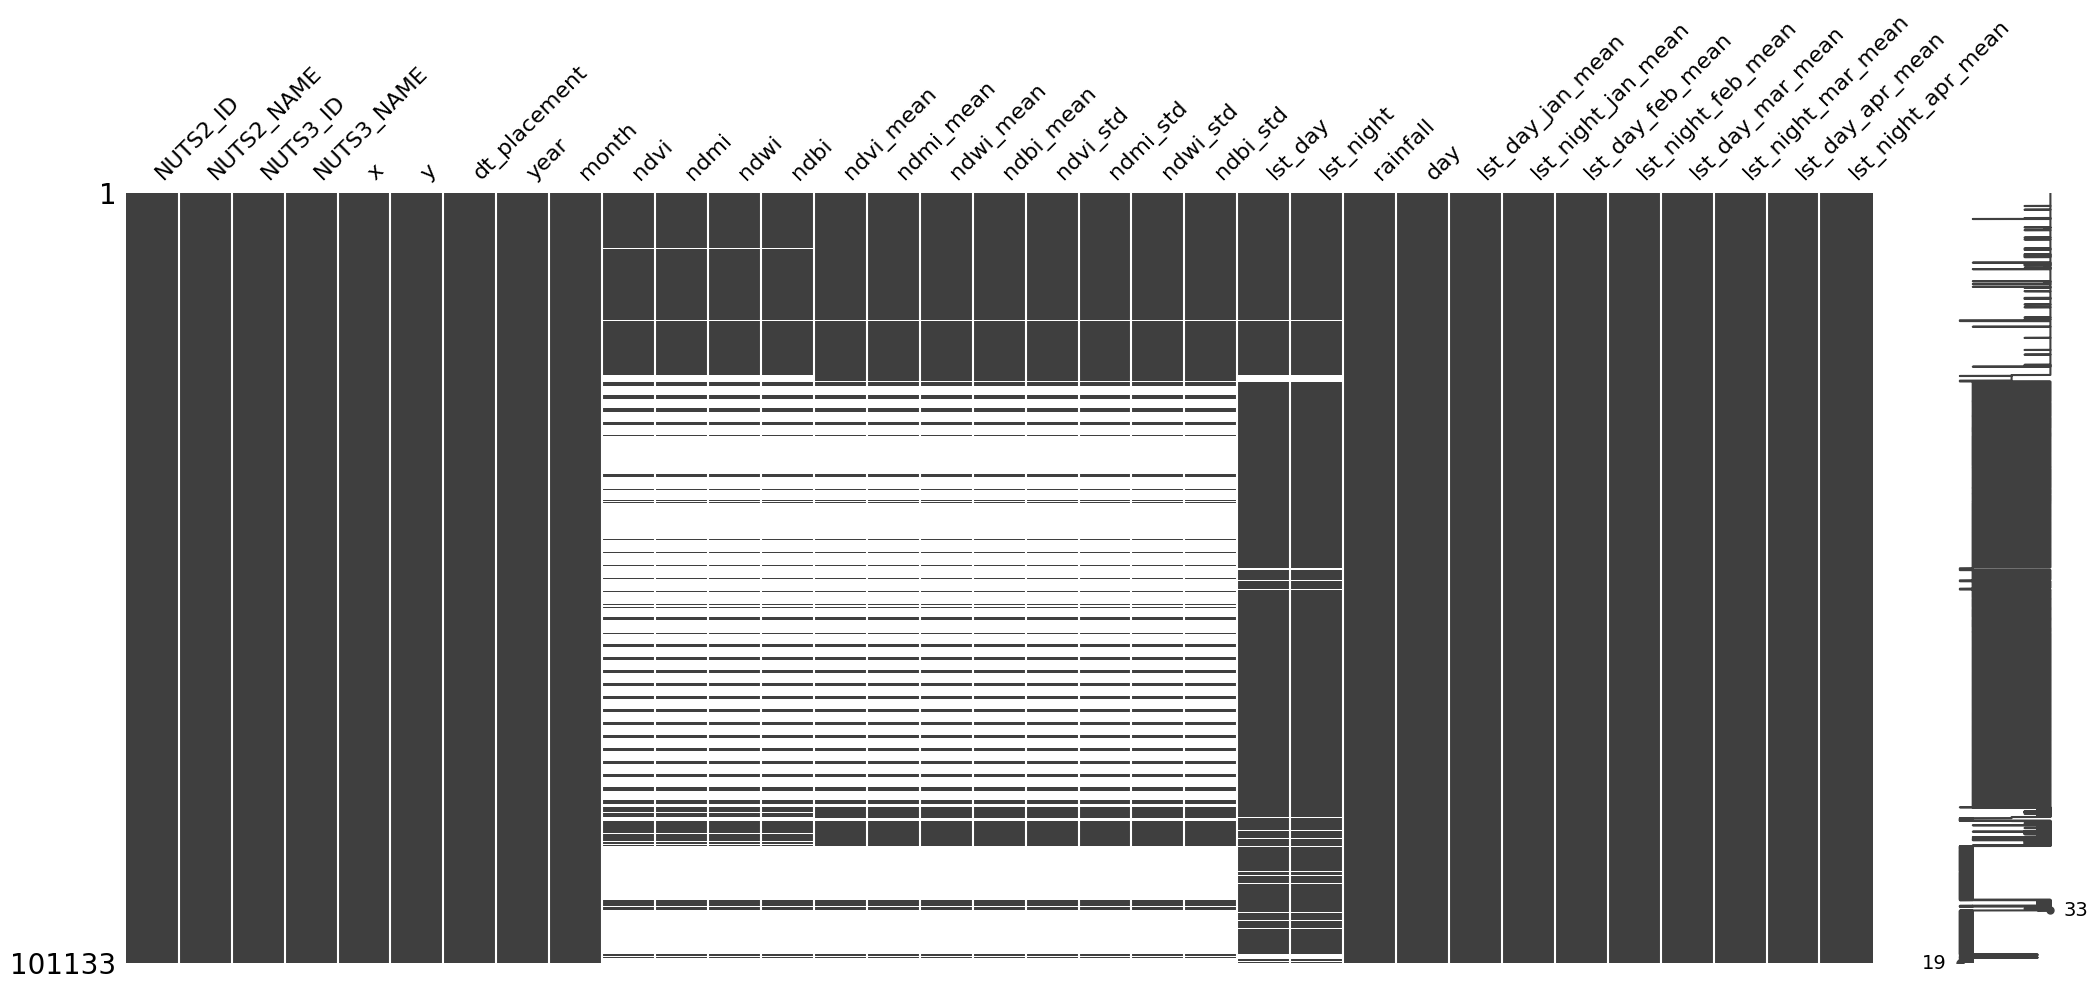

In [109]:
missingno.matrix(data_mean)

In [110]:
data_mean.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled_mean.csv', encoding='utf-8')